# API (application programming interface)
In simple words it is a messenger that takes requests and tells a system what you want to do and then returns the response back to you .

- It is a way for two or more computer programs to communicate with each other .
- here we will see how to use APIs to get data from the web .

In [1]:
import pandas as pd
import requests

In [37]:
response = requests.get("https://api.themoviedb.org/3/tv/popular?api_key=4035eaa90cb0288f5ef8de98fd236154&page=1")
# <Response [200]> means the request was successful .

In [39]:
temp = pd.DataFrame(response.json()['results'])[["id", "name", "overview","origin_country","original_language", "popularity", "vote_average", "vote_count", "first_air_date"]]
temp.shape

(20, 9)

In [40]:
temp.head(3)

,id,name,overview,origin_country,original_language,popularity,vote_average,vote_count,first_air_date
0,119051,Wednesday,"Smart, sarcastic and a little dead inside, Wed...",[US],en,318.7812,8.392,9781,2022-11-23
1,194766,The Summer I Turned Pretty,"Every summer, Belly and her family head to the...",[US],en,266.2929,8.173,956,2022-06-16
2,157239,Alien: Earth,When the mysterious deep space research vessel...,[US],en,229.4961,7.708,427,2025-08-12


In [41]:
Dataf = pd.DataFrame()

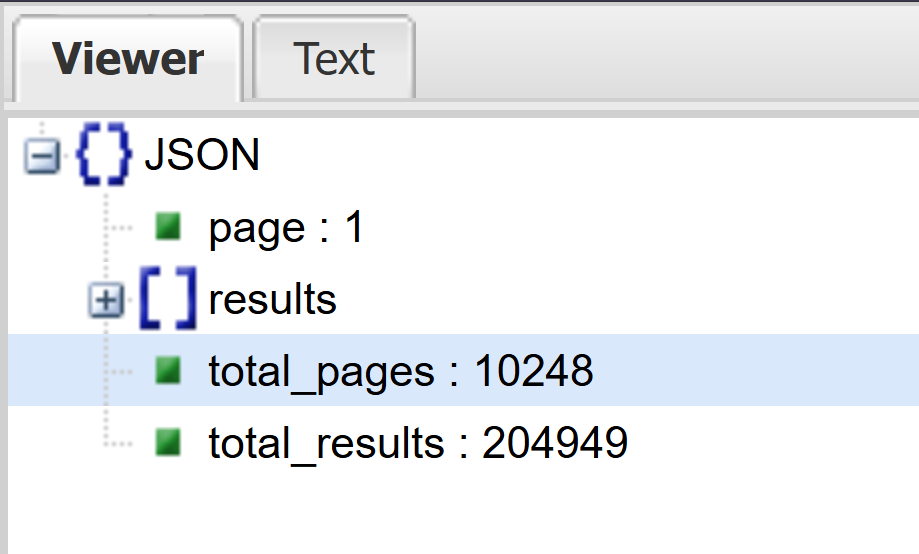
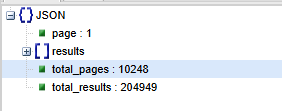

In [46]:
for i in range(1,10249):
    response = requests.get(f"https://api.themoviedb.org/3/tv/popular?api_key=4035eaa90cb0288f5ef8de98fd236154&page={i}")
    temp_df = pd.DataFrame(response.json()['results'])[["id", "name", "overview","origin_country","original_language", "popularity", "vote_average", "vote_count", "first_air_date"]]
    Dataf = pd.concat([Dataf, temp_df], ignore_index=True)      # here ignore_index=True is used to avoid duplicate index values (for every page the index starts from 0) , so it will reset the index .

KeyError: 'results'

In [18]:
import os
import time
import requests
import pandas as pd

# Provide one of these via environment variables or paste directly
V3_API_KEY = os.getenv("TMDB_V3_API_KEY", "4035eaa90cb0288f5ef8de98fd236154").strip()      # example: "4035eaa90cb0288f5ef8de98fd236154"
V4_TOKEN   = os.getenv("TMDB_V4_TOKEN", "").strip()         # example: "eyJhbGciOiJIUzI1NiJ9...."

BASE_URL = "https://api.themoviedb.org/3"
ENDPOINT = "/tv/popular"
# TMDB commonly limits list endpoints to the first 500 pages
HARD_PAGE_CAP = 500

def make_session():
    s = requests.Session()
    s.headers.update({"accept": "application/json"})
    if V4_TOKEN:
        s.headers.update({"Authorization": f"Bearer {V4_TOKEN}"})
    return s

def get_page(session: requests.Session, page: int):
    params = {"page": page}
    # If no V4 token, fall back to v3 api_key in query
    if not V4_TOKEN:
        if not V3_API_KEY:
            raise RuntimeError("Provide either TMDB_V4_TOKEN or TMDB_V3_API_KEY.")
        params["api_key"] = V3_API_KEY

    url = f"{BASE_URL}{ENDPOINT}"
    r = session.get(url, params=params, timeout=30)
    if r.status_code == 429:
        # Too many requests -> backoff and retry once
        retry_after = int(r.headers.get("Retry-After", "2"))
        time.sleep(retry_after)
        r = session.get(url, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

def main():
    session = make_session()
    first = get_page(session, 1)
    total_pages = first.get("total_pages", 1)
    total_results = first.get("total_results", 0)
    print(f"Total results reported: {total_results}, total pages reported: {total_pages}")

    # Respect TMDB hard page cap if present
    max_pages = min(total_pages, HARD_PAGE_CAP)

    all_results = []
    all_results.extend(first.get("results", []))

    # Be gentle with rate limits. ~5 req/sec is usually safe.
    for page in range(2, max_pages + 1):
        data = get_page(session, page)
        results = data.get("results", [])
        if not results:
            break
        all_results.extend(results)
        # small sleep to avoid rate limiting bursts
        time.sleep(0.2)

    df = pd.json_normalize(all_results)
    print("DataFrame shape:", df.shape)
    print(df.head(3))

    # Save if you want
    df.to_csv("tmdb_tv_popular.csv", index=False)
    print("Saved tmdb_tv_popular.csv")

if __name__ == "__main__":
    main()

Total results reported: 204949, total pages reported: 10248
DataFrame shape: (10000, 14)
   adult                     backdrop_path          genre_ids      id  \
0  False  /iHSwvRVsRyxpX7FE7GbviaDvgGZ.jpg  [10765, 9648, 35]  119051   
1  False  /jCcSS9iDpKgll8Kpp7qVhSn0l1f.jpg               [18]  194766   
2  False  /biIBy2LPOOtGCgUYOls3dUEWU3v.jpg        [10765, 18]  157239   

  origin_country original_language               original_name  \
0           [US]                en                   Wednesday   
1           [US]                en  The Summer I Turned Pretty   
2           [US]                en                Alien: Earth   

                                            overview  popularity  \
0  Smart, sarcastic and a little dead inside, Wed...    318.7812   
1  Every summer, Belly and her family head to the...    266.2929   
2  When the mysterious deep space research vessel...    229.4961   

                        poster_path first_air_date  \
0  /36xXlhEpQqVVPuiZhfoQua

In [30]:
df = pd.read_csv("tmdb_tv_popular.csv")
df.shape

(10000, 14)

In [31]:
df.head(3)

,adult,backdrop_path,genre_ids,id,origin_country,original_language,original_name,overview,popularity,poster_path,first_air_date,name,vote_average,vote_count
0,False,/iHSwvRVsRyxpX7FE7GbviaDvgGZ.jpg,"[10765, 9648, 35]",119051,['US'],en,Wednesday,"Smart, sarcastic and a little dead inside, Wed...",318.7812,/36xXlhEpQqVVPuiZhfoQuaY4OlA.jpg,2022-11-23,Wednesday,8.392,9781
1,False,/jCcSS9iDpKgll8Kpp7qVhSn0l1f.jpg,[18],194766,['US'],en,The Summer I Turned Pretty,"Every summer, Belly and her family head to the...",266.2929,/xBIz53wYWsKfFpN0TaizVAjKJ0z.jpg,2022-06-16,The Summer I Turned Pretty,8.173,956
2,False,/biIBy2LPOOtGCgUYOls3dUEWU3v.jpg,"[10765, 18]",157239,['US'],en,Alien: Earth,When the mysterious deep space research vessel...,229.4961,/yueXS3q8BtoWekcHOATFHicLl3e.jpg,2025-08-12,Alien: Earth,7.708,427


In [33]:
df = df[["id", "name", "overview","origin_country","original_language", "popularity", "vote_average", "vote_count", "first_air_date"]]

In [34]:
df

,id,name,overview,origin_country,original_language,popularity,vote_average,vote_count,first_air_date
0,119051,Wednesday,"Smart, sarcastic and a little dead inside, Wed...",['US'],en,318.7812,8.392,9781,2022-11-23
1,194766,The Summer I Turned Pretty,"Every summer, Belly and her family head to the...",['US'],en,266.2929,8.173,956,2022-06-16
2,157239,Alien: Earth,When the mysterious deep space research vessel...,['US'],en,229.4961,7.708,427,2025-08-12
3,1405,Dexter,"Dexter Morgan, a blood spatter pattern analyst...",['US'],en,194.8342,8.215,4900,2006-10-01
4,2734,Law & Order: Special Victims Unit,"In the criminal justice system, sexually-based...",['US'],en,174.1633,7.936,4010,1999-09-20
...,...,...,...,...,...,...,...,...,...
9995,13531,The Beatles,The Beatles is an American animated television...,"['AU', 'GB', 'US']",en,2.9645,5.300,10,1965-09-25
9996,73068,Begin Again,A variety show gathering some of Korea’s best ...,['KR'],ko,2.8724,8.000,8,2017-06-25
9997,12146,Shelley,"James Shelley, an educated, sardonic, permanen...",['GB'],en,4.5563,8.000,9,1979-07-12
9998,91678,Queendom,A musical battle between 6 trending girl group...,['KR'],ko,3.4961,7.500,13,2019-08-29
